**Table of contents**<a id='toc0_'></a>    
- [Imports](#toc1_)    
- [Load Data set](#toc2_)    
- [Understanding Data](#toc3_)    
- [Global constants](#toc4_)    
- [Model 1 - Classification](#toc5_)    
  - [Selecting 5 categories and labels](#toc5_1_)    
  - [Split data to train(fit) and test(predict)](#toc5_2_)    
    - [Understanding split data](#toc5_2_1_)    
  - [Using LDA clasification](#toc5_3_)    
    - [LDA without hyper parameter tuning](#toc5_3_1_)    
    - [LDA with hyper parameter tuning](#toc5_3_2_)    
    - [LDA with normalization and hyper parameter tuning](#toc5_3_3_)    
  - [Logistic regression](#toc5_4_)    
    - [Without hyperparamter tuning](#toc5_4_1_)    
    - [With hyperparameter Tuning](#toc5_4_2_)    
    - [With Normalization](#toc5_4_3_)    
- [Model 2 - Preprocessing with classification](#toc6_)    
  - [Prerocessing with LDA feature/dimensionality reduction](#toc6_1_)    
    - [LDA without noramlisation and no hyper parameters](#toc6_1_1_)    
    - [LDA with noramlisation and no hyper parameters](#toc6_1_2_)    
    - [LDA with noramlisation and hyper parameters](#toc6_1_3_)    
    - [Grid search optimization to find best c value](#toc6_1_4_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Imports](#toc0_)

In [89]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from matplotlib import pyplot as plt
from sklearn.linear_model import LogisticRegression
import skimage.feature
from sklearn.preprocessing import StandardScaler

# <a id='toc2_'></a>[Load Data set](#toc0_)

In [5]:
data = np.load('./DS_Xdata.npy')
labels = np.load('./Ydata.npy')

# <a id='toc3_'></a>[Understanding Data](#toc0_)

In [6]:
print(f"Shape: {data.shape}")
print(f"Sample count: {len(labels)}")
print(f"Unique label: {np.unique(labels)}")

Shape: (2100, 61, 61, 3)
Sample count: 2100
Unique label: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]


# <a id='toc4_'></a>[Global constants](#toc0_)

In [7]:
#Value to replicate the random value generation in the file
seeding_constant = 20

#Categories to be selected for classification
category_count = 5

# <a id='toc5_'></a>[Model 1 - Classification](#toc0_)

## <a id='toc5_1_'></a>[Selecting 5 categories and labels](#toc0_)

In [8]:
np.random.seed(seeding_constant)

unique_label_set = set(np.unique(labels))

selected_categories = [np.random.randint(min(unique_label_set), 
                                         max(unique_label_set)) 
                        for _ in range(category_count)
                        ]

selected_data = [] 
selected_labels = [] 

for index, value in enumerate(labels):
    if value[0] in selected_categories:
        selected_data.append(data[index])
        selected_labels.append(value[0])

## <a id='toc5_2_'></a>[Split data to train(fit) and test(predict)](#toc0_)

In [9]:
split_list = train_test_split(selected_data,
                              selected_labels,
                              test_size = 0.1,
                              shuffle = True,
                              random_state = seeding_constant                                      
                            )

train_model_1_and_2_data = split_list[0]
test_model_1_and_2_data = split_list[1]
train_model_1_and_2_labels = split_list[2]
test_model_1_and_2_labels = split_list[3]

### <a id='toc5_2_1_'></a>[Understanding split data](#toc0_)

In [10]:
unique_train_labels = set(np.unique(train_model_1_and_2_labels))

print("Train Data diversification")
for i in unique_train_labels:
    print(f"Label {i} : {train_model_1_and_2_labels.count(i)}")

print("--"*25)

unique_test_labels = np.unique(test_model_1_and_2_labels)
print("Test Data diversification")
for i in unique_test_labels:
    print(f"Label {i} : {test_model_1_and_2_labels.count(i)}")

Train Data diversification
Label 3 : 87
Label 7 : 91
Label 9 : 93
Label 11 : 87
Label 15 : 92
--------------------------------------------------
Test Data diversification
Label 3 : 13
Label 7 : 9
Label 9 : 7
Label 11 : 13
Label 15 : 8


## <a id='toc5_3_'></a>[Using LDA clasification](#toc0_)

In [8]:
# Reshape each image to a 1D array
num_features = np.prod(train_model_1_and_2_data[0].shape) 

train_model_1_and_2_data_reshaped = np.array([x.reshape(num_features) for x in train_model_1_and_2_data])
test_model_1_and_2_data_reshaped = np.array([x.reshape(num_features) for x in test_model_1_and_2_data])


### <a id='toc5_3_1_'></a>[LDA without hyper parameter tuning](#toc0_)

In [9]:
lda= LDA(n_components=3)
lda.fit(train_model_1_and_2_data_reshaped, train_model_1_and_2_labels)

result_model1 = lda.predict(test_model_1_and_2_data_reshaped)

In [10]:
print(f"LDA Accuracy: {lda.score(test_model_1_and_2_data_reshaped, test_model_1_and_2_labels)}")

LDA Accuracy: 0.58


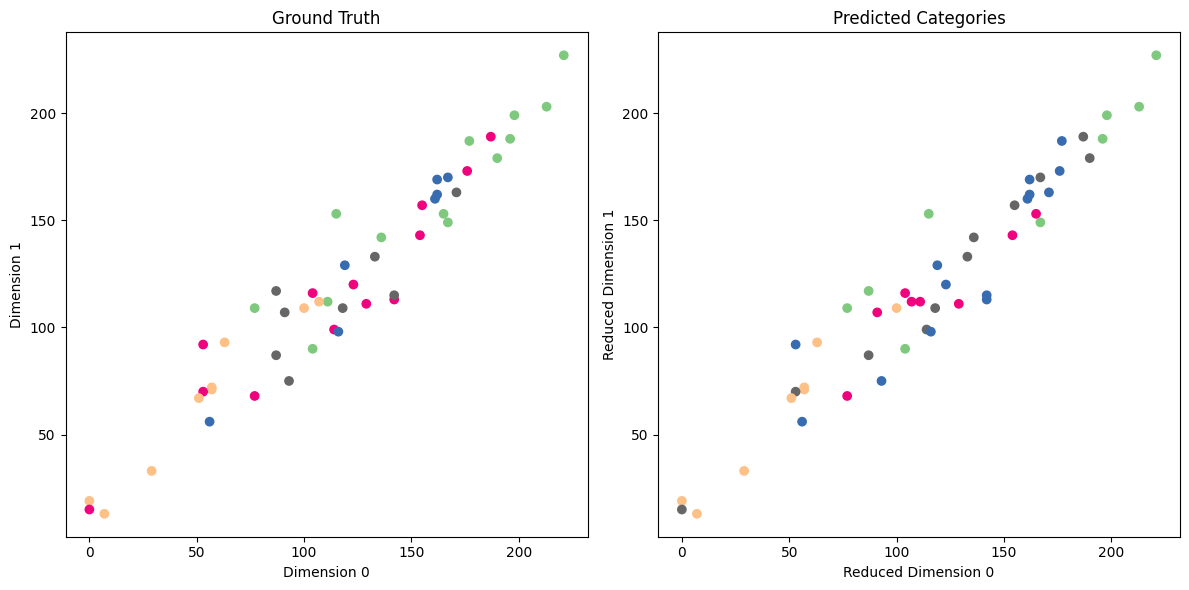

In [11]:
plt.ion()

# Create a figure with multiple subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot ground truth
axs[0].scatter(test_model_1_and_2_data_reshaped[:,0], 
               test_model_1_and_2_data_reshaped[:,1],
               c=test_model_1_and_2_labels,
               cmap='Accent')
axs[0].set_xlabel("Dimension 0")
axs[0].set_ylabel("Dimension 1")
axs[0].set_title("Ground Truth")

#Plot predicted truth
axs[1].scatter(test_model_1_and_2_data_reshaped[:,0], 
               test_model_1_and_2_data_reshaped[:,1],
               c=result_model1,
               cmap='Accent')
axs[1].set_xlabel("Reduced Dimension 0")
axs[1].set_ylabel("Reduced Dimension 1")
axs[1].set_title("Predicted Categories")

# Layout so plots do not overlap
fig.tight_layout()

plt.show()

### <a id='toc5_3_2_'></a>[LDA with hyper parameter tuning](#toc0_)

In [35]:
lda2= LDA(n_components=4, solver="eigen", shrinkage='auto' )
lda2.fit(train_model_1_and_2_data_reshaped, train_model_1_and_2_labels)

result2_model1 = lda2.predict(test_model_1_and_2_data_reshaped)


In [36]:
print(lda2.score(test_model_1_and_2_data_reshaped, test_model_1_and_2_labels))

0.6


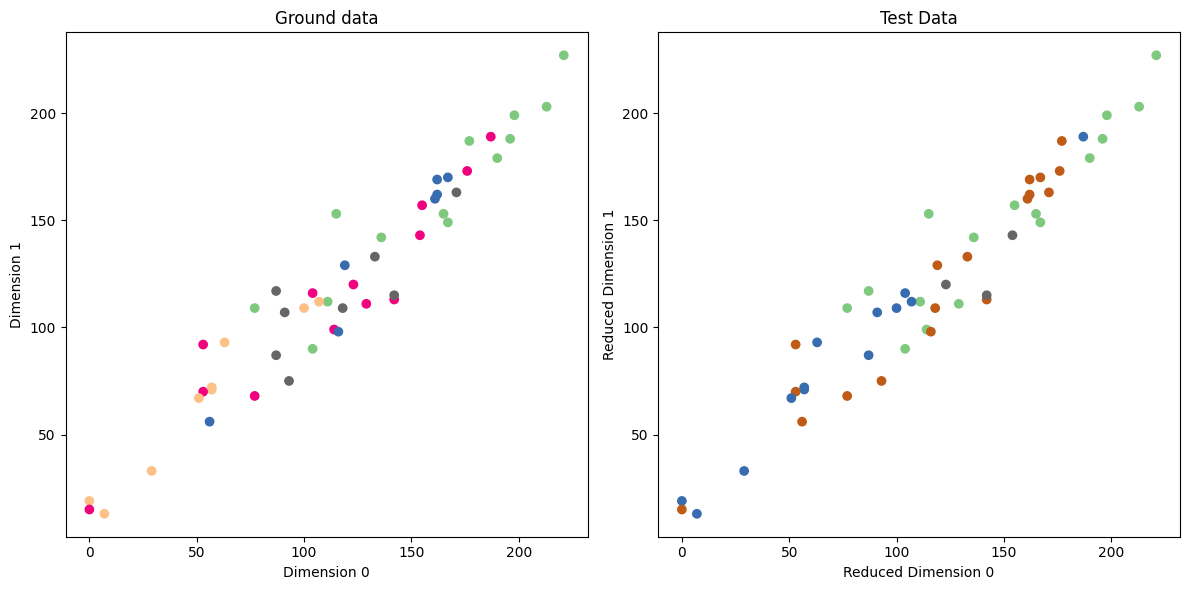

In [ ]:
plt.ion()

# Create a figure with multiple subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot ground truth
axs[0].scatter(test_model_1_and_2_data_reshaped[:,0], 
               test_model_1_and_2_data_reshaped[:,1],
               c=test_model_1_and_2_labels,
               cmap='Accent')
axs[0].set_xlabel("Dimension 0")
axs[0].set_ylabel("Dimension 1")
axs[0].set_title("Ground Truth")

#Plot predicted truth
axs[1].scatter(test_model_1_and_2_data_reshaped[:,0], 
               test_model_1_and_2_data_reshaped[:,1],
               c=result2_model1,
               cmap='Accent')
axs[1].set_xlabel("Reduced Dimension 0")
axs[1].set_ylabel("Reduced Dimension 1")
axs[1].set_title("Predicted Categories")

# Layout so plots do not overlap
fig.tight_layout()

plt.show()

### <a id='toc5_3_3_'></a>[LDA with normalization and hyper parameter tuning](#toc0_)

In [38]:
lda3= LDA(n_components=4, solver="eigen", shrinkage='auto' )

normalized_train_data = train_model_1_and_2_data_reshaped/255
normalized_test_data = test_model_1_and_2_data_reshaped/255

lda3.fit(normalized_train_data, train_model_1_and_2_labels)

result3_model1 = lda3.predict(normalized_test_data)


In [39]:
print(lda3.score(normalized_test_data, test_model_1_and_2_labels))

0.6


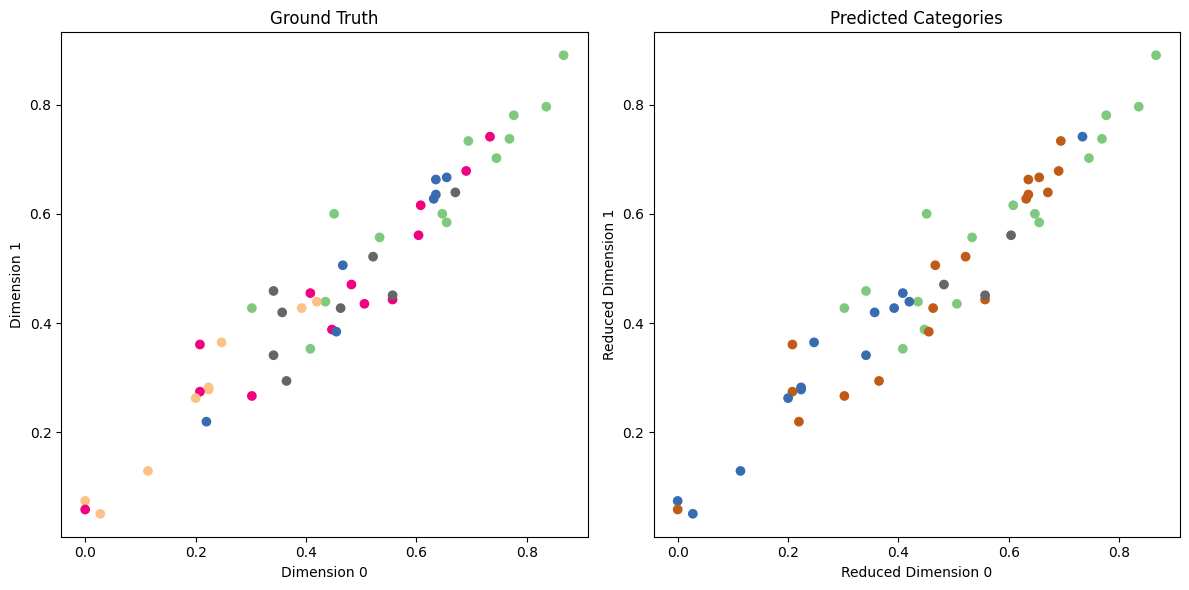

In [ ]:
plt.ion()

# Create a figure with multiple subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot ground truth
axs[0].scatter(normalized_test_data[:,0], 
               normalized_test_data[:,1],
               c=test_model_1_and_2_labels,
               cmap='Accent')
axs[0].set_xlabel("Dimension 0")
axs[0].set_ylabel("Dimension 1")
axs[0].set_title("Ground Truth")

#Plot predicted truth
axs[1].scatter(normalized_test_data[:,0], 
               normalized_test_data[:,1],
               c=result3_model1,
               cmap='Accent')
axs[1].set_xlabel("Reduced Dimension 0")
axs[1].set_ylabel("Reduced Dimension 1")
axs[1].set_title("Predicted Categories")

# Layout so plots do not overlap
fig.tight_layout()

plt.show()

## <a id='toc5_4_'></a>[Logistic regression](#toc0_)

### <a id='toc5_4_1_'></a>[Without hyperparamter tuning](#toc0_)

In [12]:
# Train a classifier on the reduced training data
classifier1 = LogisticRegression(max_iter=1000)
classifier1.fit(train_model_1_and_2_data_reshaped, train_model_1_and_2_labels)

# Predict labels for the reduced test data
predicted_labels1 = classifier1.predict(test_model_1_and_2_data_reshaped)

print(classifier1.score(test_model_1_and_2_data_reshaped, test_model_1_and_2_labels))

0.6


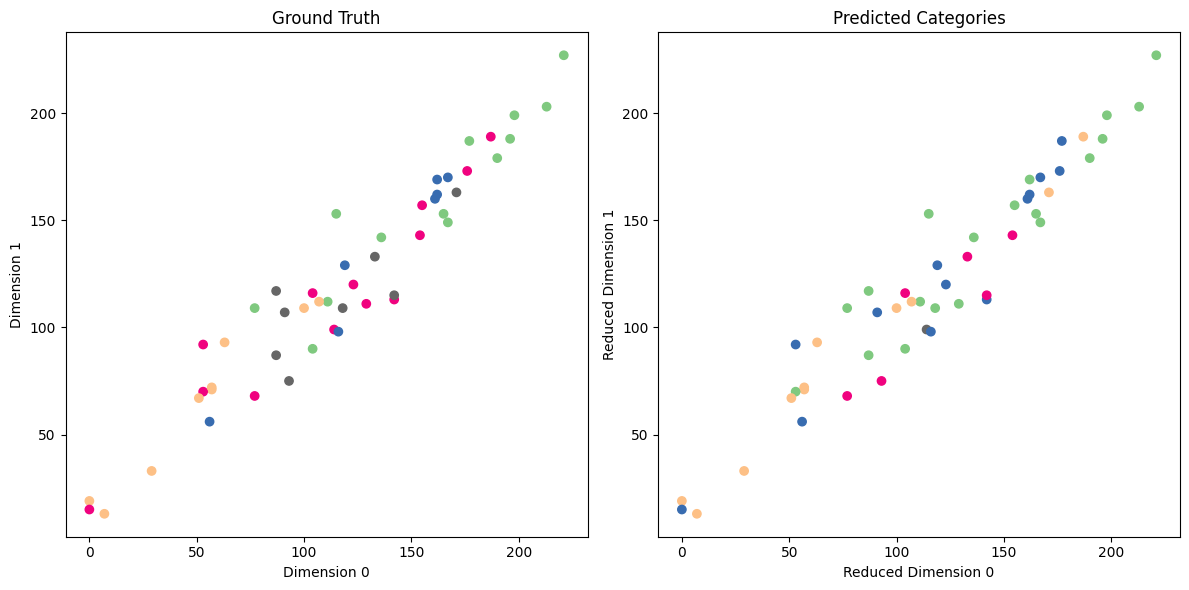

In [13]:
plt.ion()

# Create a figure with multiple subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot ground truth
axs[0].scatter(test_model_1_and_2_data_reshaped[:,0], 
               test_model_1_and_2_data_reshaped[:,1],
               c=test_model_1_and_2_labels,
               cmap='Accent')
axs[0].set_xlabel("Dimension 0")
axs[0].set_ylabel("Dimension 1")
axs[0].set_title("Ground Truth")

#Plot predicted truth
axs[1].scatter(test_model_1_and_2_data_reshaped[:,0], 
               test_model_1_and_2_data_reshaped[:,1],
               c=predicted_labels1,
               cmap='Accent')
axs[1].set_xlabel("Reduced Dimension 0")
axs[1].set_ylabel("Reduced Dimension 1")
axs[1].set_title("Predicted Categories")

# Layout so plots do not overlap
fig.tight_layout()

plt.show()

### <a id='toc5_4_2_'></a>[With hyperparameter Tuning](#toc0_)

In [14]:
# Train a classifier on the reduced training data
classifier2 = LogisticRegression(max_iter=2500, solver='sag', C=15)
classifier2.fit(train_model_1_and_2_data_reshaped, train_model_1_and_2_labels)

# Predict labels for the reduced test data
predicted_labels2 = classifier2.predict(test_model_1_and_2_data_reshaped)

print(classifier2.score(test_model_1_and_2_data_reshaped, test_model_1_and_2_labels))

0.54


### <a id='toc5_4_3_'></a>[With Normalization](#toc0_)

In [15]:
normalized_train_data = train_model_1_and_2_data_reshaped/255
normalized_test_data = test_model_1_and_2_data_reshaped/255

# Train a classifier on the reduced training data
classifier3 = LogisticRegression(max_iter=1000)
classifier3.fit(normalized_train_data, train_model_1_and_2_labels)

# Predict labels for the reduced test data
predicted_labels3 = classifier3.predict(normalized_test_data)

print(classifier3.score(normalized_test_data, test_model_1_and_2_labels))

0.62


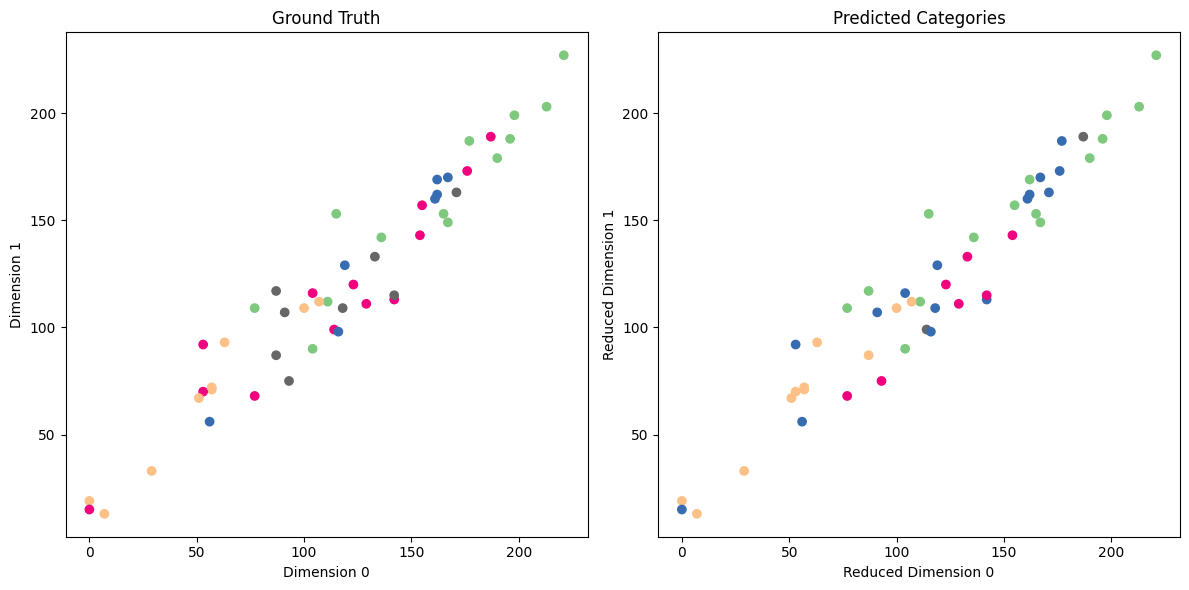

In [ ]:
plt.ion()

# Create a figure with multiple subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot ground truth
axs[0].scatter(test_model_1_and_2_data_reshaped[:,0], 
               test_model_1_and_2_data_reshaped[:,1],
               c=test_model_1_and_2_labels,
               cmap='Accent')
axs[0].set_xlabel("Dimension 0")
axs[0].set_ylabel("Dimension 1")
axs[0].set_title("Ground Truth")

#Plot predicted truth
axs[1].scatter(test_model_1_and_2_data_reshaped[:,0], 
               test_model_1_and_2_data_reshaped[:,1],
               c=predicted_labels3,
               cmap='Accent')
axs[1].set_xlabel("Reduced Dimension 0")
axs[1].set_ylabel("Reduced Dimension 1")
axs[1].set_title("Predicted Categories")

# Layout so plots do not overlap
fig.tight_layout()

plt.show()

# <a id='toc6_'></a>[Model 2 - Preprocessing with classification](#toc0_)

In [10]:
# Reshape each image to a 1D array
num_features = np.prod(train_model_1_and_2_data[0].shape) 

train_model_1_and_2_data_reshaped = np.array([x.reshape(num_features) for x in train_model_1_and_2_data])
test_model_1_and_2_data_reshaped = np.array([x.reshape(num_features) for x in test_model_1_and_2_data])

## <a id='toc6_1_'></a>[Prerocessing with LDA feature/dimensionality reduction](#toc0_)

### <a id='toc6_1_1_'></a>[LDA without noramlisation and no hyper parameters](#toc0_)

In [99]:
lda4= LDA(n_components=4)
train_transformed1_moldel2 = lda4.fit_transform(train_model_1_and_2_data_reshaped, train_model_1_and_2_labels)

test_transformed1_moldel2 = lda4.transform(test_model_1_and_2_data_reshaped)

In [100]:
# Train a classifier on the reduced training data
classifier4 = LogisticRegression(max_iter=1000)
classifier4.fit(train_transformed1_moldel2, train_model_1_and_2_labels)

# Predict labels for the reduced test data
predicted_labels4 = classifier4.predict(test_transformed1_moldel2)

print(classifier4.score(test_transformed1_moldel2, test_model_1_and_2_labels))

0.62


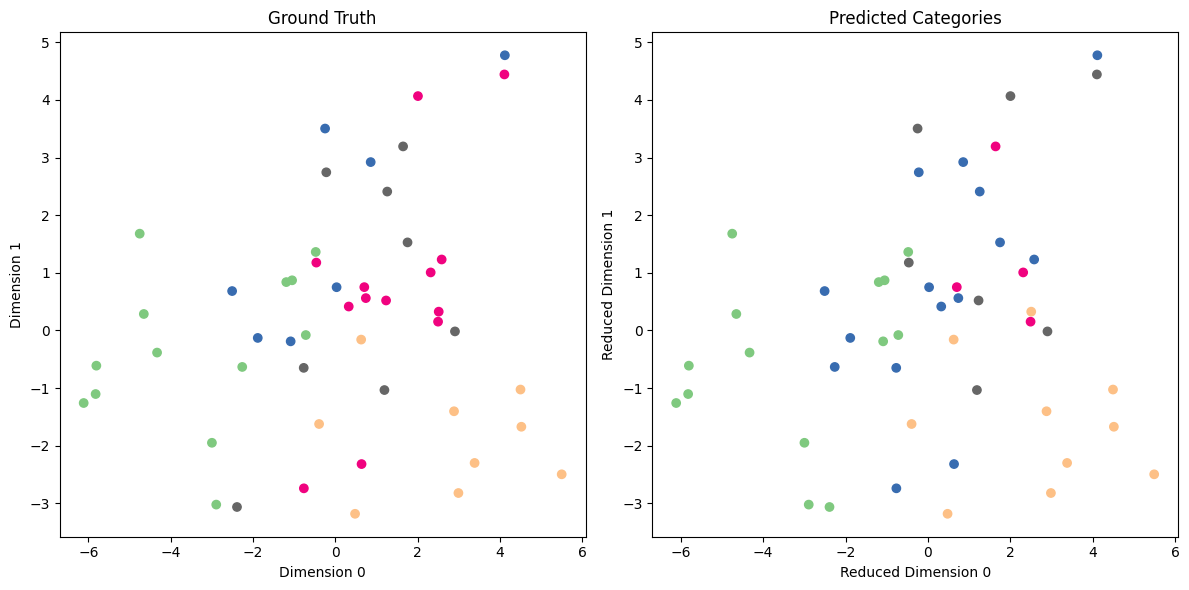

In [101]:
plt.ion()

# Create a figure with multiple subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot ground truth
axs[0].scatter(test_transformed1_moldel2[:,0], 
               test_transformed1_moldel2[:,1],
               c=test_model_1_and_2_labels,
               cmap='Accent')
axs[0].set_xlabel("Dimension 0")
axs[0].set_ylabel("Dimension 1")
axs[0].set_title("Ground Truth")

#Plot predicted truth
axs[1].scatter(test_transformed1_moldel2[:,0], 
               test_transformed1_moldel2[:,1],
               c=predicted_labels4,
               cmap='Accent')
axs[1].set_xlabel("Reduced Dimension 0")
axs[1].set_ylabel("Reduced Dimension 1")
axs[1].set_title("Predicted Categories")

# Layout so plots do not overlap
fig.tight_layout()

plt.show()

### <a id='toc6_1_2_'></a>[LDA with noramlisation and no hyper parameters](#toc0_)

In [12]:
normalized_train_data = train_model_1_and_2_data_reshaped/255
normalized_test_data = test_model_1_and_2_data_reshaped/255

In [14]:
lda5= LDA(n_components=4, )
train_transformed2_moldel2 = lda5.fit_transform(normalized_train_data, train_model_1_and_2_labels)

test_transformed2_moldel2 = lda5.transform(normalized_test_data)


In [15]:
# Train a classifier on the reduced training data
classifier5 = LogisticRegression(max_iter=1000)
classifier5.fit(train_transformed2_moldel2, train_model_1_and_2_labels)

# Predict labels for the reduced test data
predicted_labels5 = classifier5.predict(test_transformed2_moldel2)

print(classifier5.score(test_transformed2_moldel2, test_model_1_and_2_labels))

0.62


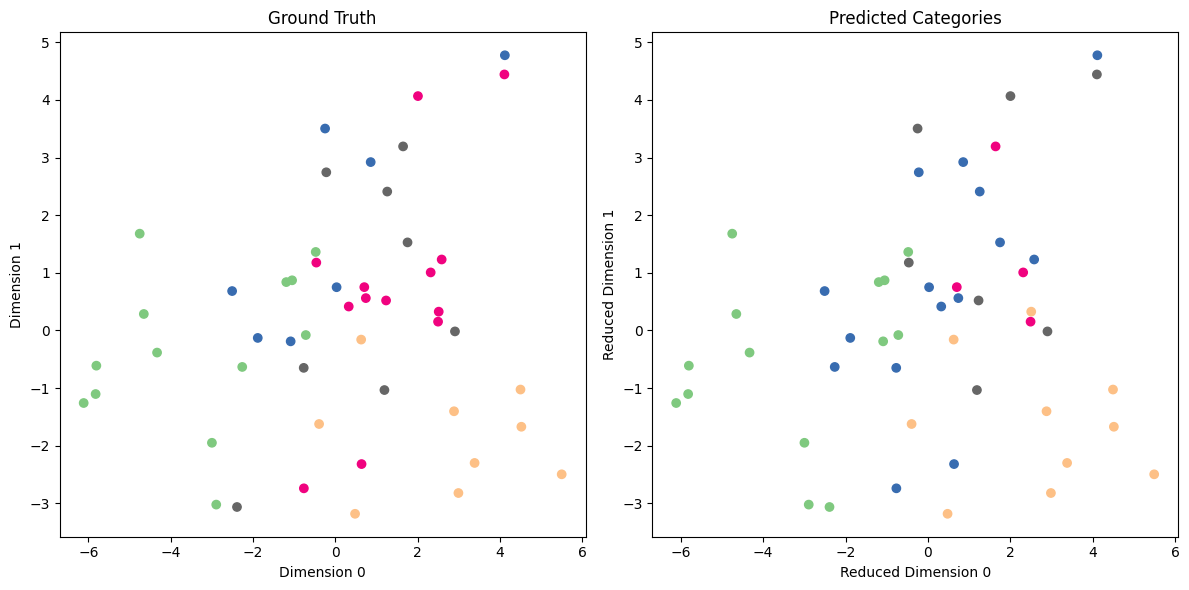

In [16]:
plt.ion()

# Create a figure with multiple subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot ground truth
axs[0].scatter(test_transformed2_moldel2[:,0], 
               test_transformed2_moldel2[:,1],
               c=test_model_1_and_2_labels,
               cmap='Accent')
axs[0].set_xlabel("Dimension 0")
axs[0].set_ylabel("Dimension 1")
axs[0].set_title("Ground Truth")

#Plot predicted truth
axs[1].scatter(test_transformed2_moldel2[:,0], 
               test_transformed2_moldel2[:,1],
               c=predicted_labels5,
               cmap='Accent')
axs[1].set_xlabel("Reduced Dimension 0")
axs[1].set_ylabel("Reduced Dimension 1")
axs[1].set_title("Predicted Categories")

# Layout so plots do not overlap
fig.tight_layout()

plt.show()

### <a id='toc6_1_3_'></a>[LDA with noramlisation and hyper parameters](#toc0_)

In [17]:
lda6= LDA(n_components=3, solver="eigen", shrinkage='auto')
train_transformed3_moldel2 = lda6.fit_transform(normalized_train_data, train_model_1_and_2_labels)

test_transformed3_moldel2 = lda6.transform(normalized_test_data)


In [21]:
classifier6 = LogisticRegression(max_iter=1000, C=5.294)
classifier6.fit(train_transformed3_moldel2, train_model_1_and_2_labels)

# Predict labels for the reduced test data
predicted_labels6 = classifier6.predict(test_transformed3_moldel2)
print(f"{classifier6.score(test_transformed3_moldel2, test_model_1_and_2_labels)}")

0.6


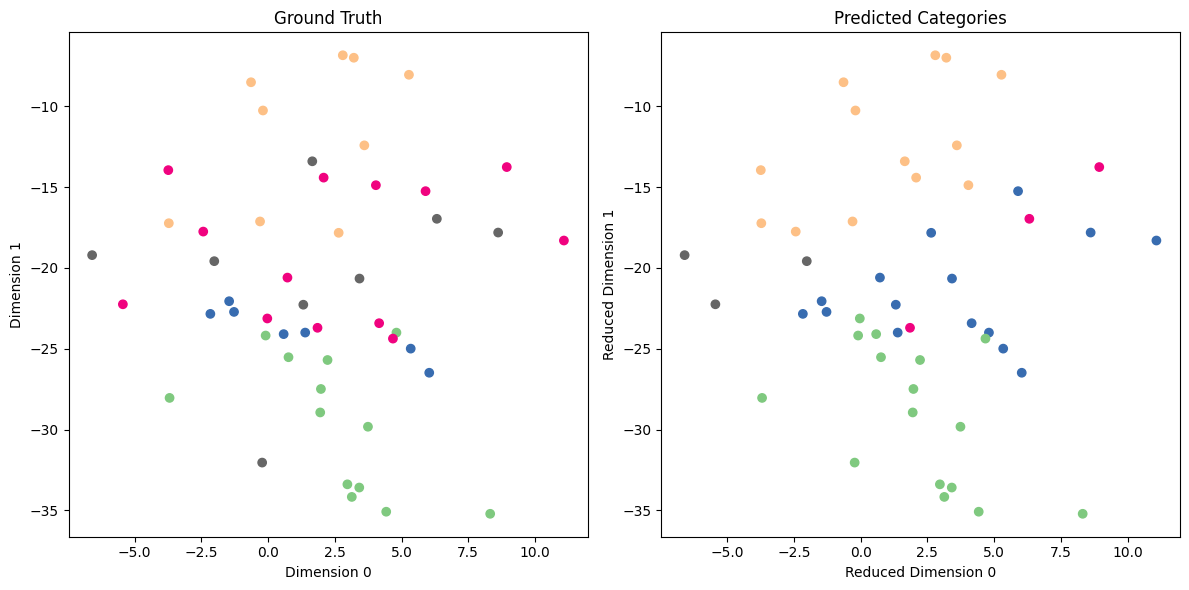

In [22]:
plt.ion()

# Create a figure with multiple subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot ground truth
axs[0].scatter(test_transformed3_moldel2[:,0], 
               test_transformed3_moldel2[:,1],
               c=test_model_1_and_2_labels,
               cmap='Accent')
axs[0].set_xlabel("Dimension 0")
axs[0].set_ylabel("Dimension 1")
axs[0].set_title("Ground Truth")

#Plot predicted truth
axs[1].scatter(test_transformed3_moldel2[:,0], 
               test_transformed3_moldel2[:,1],
               c=predicted_labels6,
               cmap='Accent')
axs[1].set_xlabel("Reduced Dimension 0")
axs[1].set_ylabel("Reduced Dimension 1")
axs[1].set_title("Predicted Categories")

# Layout so plots do not overlap
fig.tight_layout()

plt.show()

#### Optimization for finding best hyper parameters

##### <a id='toc6_1_4_'></a>[Grid search optimization to find best c value](#toc0_)

In [ ]:
# Train a classifier on the reduced training data
for i in np.linspace(5, 7, 10000):
    classifier6 = LogisticRegression(max_iter=1000, C=round(float(i), 3))
    classifier6.fit(train_transformed3_moldel2, train_model_1_and_2_labels)

    # Predict labels for the reduced test data
    predicted_labels6 = classifier6.predict(test_transformed3_moldel2)
    score = classifier6.score(test_transformed3_moldel2, test_model_1_and_2_labels)
    if(score>0.58):
        print(f"{round(float(i), 3)}:{score}")

5.294:0.6
5.294:0.6
5.294:0.6
5.294:0.6
5.294:0.6
6.091:0.6
6.091:0.6
6.091:0.6
6.091:0.6
6.091:0.6


##### SA search

In [173]:
from scipy.optimize import dual_annealing
from sklearn.model_selection import cross_val_score
from sklearn.multiclass import OneVsRestClassifier

# Objective function for Simulated Annealing
def objective(params):
    C, penalty_idx, solver_idx = params

     
    try:
        float(C)
        int(penalty_idx)
        int(solver_idx)
        if C <= 0 or penalty_idx < 0 or solver_idx < 0:
            return np.inf
    except:
        return np.inf
    
    
    C = round(C, 3)


    penalties = ['l2', 'elasticnet']
    solvers = ['newton-cg', 'sag', 'saga']
    
    penalty = penalties[int(penalty_idx)]
    solver = solvers[int(solver_idx)]

    # Ensure compatibility between solver and penalty
    if penalty == 'elasticnet' and solver!='saga':
        return np.inf
    
    try:
        # Logistic Regression model
        model = LogisticRegression(C=C, penalty=penalty, solver=solver, max_iter=5000)
        
        # Cross-validated accuracy
        score = cross_val_score(model, test_transformed3_moldel2, test_model_1_and_2_labels, cv=5, scoring='accuracy').mean()
        
        if np.isnan(score):
            return np.inf

        return -score  # Negative because `dual_annealing` minimizes
    except Exception as e:
        return np.inf  # Return a very low score if an error occurs

# Define bounds for each parameter
bounds = [
    (3, 7),          # C: Regularization strength
    (0, 1.99),            # Penalty index: 0 = 'l2', 1 = 'elasticnet'
    (0, 2.99)           # Multi-class index: 0 = 'ovr', 1 = 'multinomial'
]

# Run dual annealing
result = dual_annealing(objective, bounds, maxiter=1000)
best_params = result.x
print("Best Parameters (Raw Indices):", best_params)

# Convert indices to parameter values
best_C = best_params[0]
best_penalty = ['l2', 'elasticnet'][int(best_params[1])]
best_solver = ['lbfgs', 'newton-cg', 'sag', 'saga'][int(best_params[2])]

print("Best C:", best_C)
print("Best Penalty:", best_penalty)
print("Best Solver:", best_solver)
print("Best Cross-Validated Accuracy:", -result.fun)


Best Parameters (Raw Indices): [6.14928952 0.74353852 0.73879482]
Best C: 6.1492895236297915
Best Penalty: l2
Best Solver: lbfgs
Best Cross-Validated Accuracy: 0.54


In [164]:
classifier6 = LogisticRegression(max_iter=1000, C=5.294)
classifier6.fit(train_transformed3_moldel2, train_model_1_and_2_labels)

# Predict labels for the reduced test data
predicted_labels6 = classifier6.predict(test_transformed3_moldel2)
score = classifier6.score(test_transformed3_moldel2, test_model_1_and_2_labels)
print(score)

0.6


## Prerocessing with HOG feature extraction reduction

In [85]:
hog_features = []
#Best 10, 5
for index, image in enumerate(np.array(selected_data)):
    hog_feature, hog_image = skimage.feature.hog(image, 
                                                 pixels_per_cell=[10, 10], 
                                                 cells_per_block=[5, 5], 
                                                 visualize=True,
                                                 channel_axis=2
                                                )

    hog_features.append(hog_feature)

In [86]:
np.array(hog_features).shape

(500, 900)

In [87]:
split_list_post_hog = train_test_split(hog_features,
                                       selected_labels,
                              test_size = 0.1,
                              shuffle = True,
                              random_state = seeding_constant                                      
                            )

train_data_post_hog = np.array(split_list_post_hog[0])
test_data_post_hog = np.array(split_list_post_hog[1])

train_labels_post_hog = np.array(split_list_post_hog[2])
test_labels_post_hog = np.array(split_list_post_hog[3])


In [88]:
classifier7 = LogisticRegression(max_iter=1000)
classifier7.fit(train_data_post_hog, train_labels_post_hog)

# Predict labels for the reduced test data
predicted_labels7 = classifier7.predict(test_data_post_hog)
print(f"{classifier7.score(test_data_post_hog, test_labels_post_hog)}")

0.9


In [ ]:
scaler = StandardScaler()

# Fit the scaler to the data and transform it
scaled_train_wine_data = scaler.fit_transform(train_data_post_hog)
scaled_test_wine_data = scaler.transform(test_data_post_hog)

In [ ]:
classifier7 = LogisticRegression(max_iter=1000)
classifier7.fit(train_data_post_hog, train_labels_post_hog)

# Predict labels for the reduced test data
predicted_labels7 = classifier7.predict(test_data_post_hog)
print(f"{classifier7.score(test_data_post_hog, test_labels_post_hog)}")

In [ ]:
lda3= LDA(n_components=4, solver="eigen", shrinkage='auto' )

normalized_train_data = train_model_1_and_2_data_reshaped/255
normalized_test_data = test_model_1_and_2_data_reshaped/255

lda3.fit(normalized_train_data, train_model_1_and_2_labels)

result3_model1 = lda3.predict(normalized_test_data)


## Prerocessing with LBP feature extraction reduction

In [49]:
from skimage.feature import local_binary_pattern
# Parameters for LBP
radius = 3  # Radius of the circular LBP
n_points = 8 * radius  # Number of points for the circular neighborhood
method = 'uniform'  # Uniform LBP method

lbp_features = []

for index, image in enumerate(np.array(selected_data)):
    # Ensure the image is grayscale
    if image.ndim == 3:  # Convert RGB to grayscale
        gray_image = skimage.color.rgb2gray(image)
    else:
        gray_image = image

    # Extract LBP features
    lbp = local_binary_pattern(gray_image, n_points, radius, method)
    
    # Flatten the LBP histogram to a feature vector
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, 901), range=(0, 901))
    lbp_hist = lbp_hist.astype("float")
    lbp_hist /= lbp_hist.sum()  # Normalize the histogram
    
    # Append to features list
    lbp_features.append(lbp_hist)

# Convert to NumPy array for further processing
lbp_features = np.array(lbp_features)

print(f"LBP features shape: {lbp_features.shape}")


LBP features shape: (500, 900)


In [50]:
split_list_post_lbp = train_test_split(lbp_features,
                                       selected_labels,
                              test_size = 0.1,
                              shuffle = True,
                              random_state = seeding_constant                                      
                            )

train_data_post_lbp = np.array(split_list_post_lbp[0])
test_data_post_lbp = np.array(split_list_post_lbp[1])

train_labels_post_lbp = np.array(split_list_post_lbp[2])
test_labels_post_lbp = np.array(split_list_post_lbp[3])

In [51]:
classifier8 = LogisticRegression(max_iter=1000)
classifier8.fit(train_data_post_lbp, train_labels_post_lbp)

# Predict labels for the reduced test data
predicted_labels8 = classifier8.predict(test_data_post_lbp)
print(f"{classifier8.score(test_data_post_lbp, test_labels_post_lbp)}")

0.52


### Combining HOG and LBP

In [52]:
# train_data_hog_lbp=[]
# train_data_hog_lbp.extend(train_data_post_hog)
# train_data_hog_lbp.extend(train_data_post_lbp)

# test_data_hog_lbp=[]
# test_data_hog_lbp.extend(test_data_post_hog)
# test_data_hog_lbp.extend(test_data_post_lbp)

# train_labels_hog_lbp=[]
# train_labels_hog_lbp.extend(train_labels_post_hog)
# train_labels_hog_lbp.extend(train_labels_post_lbp)

# test_labels_hog_lbp=[]
# test_labels_hog_lbp.extend(test_labels_post_hog)
# test_labels_hog_lbp.extend(test_labels_post_lbp)

training_list_hog_lbp = train_test_split((train_data_post_hog + train_data_post_lbp),
                                       (train_labels_post_hog + train_labels_post_lbp),
                              test_size = 0.1,
                              shuffle = True,
                              random_state = seeding_constant                                      
                            )

testing_list_hog_lbp = train_test_split((test_data_post_hog + test_data_post_lbp),
                                       (test_labels_post_hog + test_labels_post_lbp),
                              test_size = 0.1,
                              shuffle = True,
                              random_state = seeding_constant                                      
                            )

# train_data_hog_lbp =  + training_list_hog_lbp[1]
# train_labels_hog_lbp =  + training_list_hog_lbp[3]

# test_data_hog_lbp =  + testing_list_hog_lbp[1]
# test_labels_hog_lbp =  + testing_list_hog_lbp[3]

train_data_hog_lbp = np.concatenate((training_list_hog_lbp[0], training_list_hog_lbp[1]), axis=0)
train_labels_hog_lbp = np.concatenate((training_list_hog_lbp[2], training_list_hog_lbp[3]), axis=0)

test_data_hog_lbp = np.concatenate((testing_list_hog_lbp[0], testing_list_hog_lbp[1]), axis=0)
test_labels_hog_lbp = np.concatenate((testing_list_hog_lbp[2], testing_list_hog_lbp[3]), axis=0)


In [53]:
print(np.array(train_data_post_hog).shape)
print(np.array(train_data_post_lbp).shape)

(450, 900)
(450, 900)


In [54]:
classifier9 = LogisticRegression(max_iter=1000)
classifier9.fit(train_data_hog_lbp, train_labels_hog_lbp)

# Predict labels for the reduced test data
predicted_labels9 = classifier9.predict(test_data_hog_lbp)
print(f"{classifier9.score(test_data_hog_lbp, test_labels_hog_lbp)}")

0.9


In [59]:
# Train a classifier on the reduced training data
detected_points = {}
newint=set()
for i in np.linspace(1, 10, 1000):
    c = round(float(i), 3)
    if c not in detected_points.keys():
        classifier_hog_lbp = LogisticRegression(max_iter=1000, C=c)
        classifier_hog_lbp.fit(train_data_hog_lbp, train_labels_hog_lbp)

        # Predict labels for the reduced test data
        predicted_labels__hog_lbp = classifier_hog_lbp.predict(test_data_hog_lbp)
        score = classifier_hog_lbp.score(test_data_hog_lbp, test_labels_hog_lbp)
        detected_points[c] = score
    
    if int(c) not in newint:
        print(int(c))
        newint.add(int(c))
    
    if score>0.9:
        print(f"{c, score}")

1
2
3
4
5
6
7
8
9
10
